<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/Hierchical_Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTANT :



In [1]:
path = '/content/drive/MyDrive/Thesis_Data/'

## preprocessing Data (removing outliers)

In [ ]:
def remove_outliers(df_animal):
  df_animal_filtered = df_animal[(df_animal['milk_kg'] >= 0.4) & (df_animal['milk_kg'] <= 26.5)]
  print(f"Total rows removed after milk filtering: {len(df_animal)-len(df_animal_filtered)}")
  df_animal_filtered = df_animal_filtered[(df_animal_filtered['fat_p'] >= 1.6) & (df_animal_filtered['fat_p'] <= 15.05)]
  print(f"Total rows removed after fat filtering: {len(df_animal)-len(df_animal_filtered)}")
  df_animal_filtered = df_animal_filtered[(df_animal_filtered['protein_p'] >= 2.67) & (df_animal_filtered['protein_p'] <= 6.68)]
  print(f"Total rows removed after protein filtering: {len(df_animal)-len(df_animal_filtered)}")
  df_animal_filtered = df_animal_filtered[(df_animal_filtered['SCS'] >= -2.06) & (df_animal_filtered['SCS'] <= 10.73)]
  print(f"Total rows removed after SCS filtering: {len(df_animal)-len(df_animal_filtered)}")
  df_animal_filtered = df_animal_filtered[df_animal_filtered['ECM'] <= 301]
  print(f"Total rows removed after ECM filtering: {len(df_animal)-len(df_animal_filtered)}")
  df_animal_filtered['AFC'] = pd.to_timedelta(df_animal_filtered['AFC'])
  df_animal_filtered = df_animal_filtered[(df_animal_filtered['AFC'] >= pd.Timedelta(days=720)) & (df_animal_filtered['AFC'] <= pd.Timedelta(days=1440))]
  print(f"Total rows removed after AFC filtering: {len(df_animal)-len(df_animal_filtered)}")
  print(f"Total rows after filtering: {len(df_animal_filtered)}")
  return df_animal_filtered

df_Merged_Scaled_Processed = remove_outliers(df_Merged_Scaled_uprocessed)
df_Merged_Scaled_Processed.to_csv(path + '/Final_Data/Merged_Data_Scaled_Processed.csv', index=False)
print("saved")

NameError: name 'df_Merged_Scaled_uprocessed' is not defined

In [2]:
def convert_types(df):
  df['dtb'] = pd.to_datetime(df['dtb'])
  df['dtt'] = pd.to_datetime(df['dtt'])
  df['dtc'] = pd.to_datetime(df['dtc'])
  df['AFC'] = pd.to_timedelta(df['AFC']).dt.days
  df['DIM'] = pd.to_timedelta(df['DIM']).dt.days
  return df

## Claude Method

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp

# Read ONLY the columns needed for structure — fast and tiny
meta = pd.read_csv(path + '/Final_Data/Merged_Data_Scaled_Processed.csv',usecols=["Farm_Code", "Animal_ID"])
meta["Farm_Code"] = meta["Farm_Code"].astype(str)
meta = meta.drop_duplicates()

# Define all series names at each level
bottom_series = (meta["Farm_Code"] + "/" + meta["Animal_ID"]).unique().tolist()
farm_series   = ("Farm/" + meta["Farm_Code"]).unique().tolist()
total_series  = ["Total"]

all_series = total_series + farm_series + bottom_series
n_all    = len(all_series)
n_bottom = len(bottom_series)

print(f"Total series:  {n_all}")      # ~89,905
print(f"Bottom series: {n_bottom}")   # ~89,577
print(f"Farm series:   {len(farm_series)}")   # ~327
print(f"Estimated S matrix size: {n_all * n_bottom * 1 / 1e6:.1f} MB (sparse)")

# Build S as a SPARSE matrix (boolean/int8 — not float64!)
series_idx    = {s: i for i, s in enumerate(all_series)}
bottom_idx    = {s: j for j, s in enumerate(bottom_series)}

rows, cols = [], []

for j, b in enumerate(bottom_series):
    farm_code = b.split("/")[0]   # e.g. "521513"

    # Total row
    rows.append(series_idx["Total"]); cols.append(j)

    # Farm row
    farm_name = "Farm/" + farm_code
    rows.append(series_idx[farm_name]); cols.append(j)

    # Identity row (bottom level)
    rows.append(series_idx[b]); cols.append(j)

data = np.ones(len(rows), dtype=np.int8)
S_sparse = sp.csr_matrix((data, (rows, cols)), shape=(n_all, n_bottom), dtype=np.int8)

print(f"\nS matrix memory: {S_sparse.data.nbytes / 1e6:.2f} MB (sparse)")

# Save S metadata (the actual reconciliation libraries need the labels)
pd.Series(all_series, name="series_id").to_csv("series_list.csv", index=False)
pd.Series(bottom_series, name="series_id").to_csv("bottom_series_list.csv", index=False)
sp.save_npz("S_matrix.npz", S_sparse)
print("✅ Saved: S_matrix.npz, series_list.csv, bottom_series_list.csv")

Total series:  89905
Bottom series: 89577
Farm series:   327
Estimated S matrix size: 8053.4 MB (sparse)

S matrix memory: 0.27 MB (sparse)
✅ Saved: S_matrix.npz, series_list.csv, bottom_series_list.csv


In [ ]:
import pandas as pd

CHUNKSIZE = 50_000   # tune based on your RAM
TARGET    = "milk_kg"
DATE_COL  = "dtt"

# We'll write all three levels to separate CSVs, then combine
chunk_iter = pd.read_csv(
    path + '/Final_Data/Merged_Data_Scaled_Processed.csv',
    usecols=["Farm_Code", "Animal_ID", DATE_COL, TARGET],
    chunksize=CHUNKSIZE,
    parse_dates=[DATE_COL],
)

# Accumulators (small — one row per date per level)
animal_records = []
farm_records   = []
total_records  = []

for i, chunk in enumerate(chunk_iter):
    chunk["Farm_Code"] = chunk["Farm_Code"].astype(str)
    chunk = chunk.dropna(subset=[TARGET])

    # Bottom level
    agg_animal = (
        chunk.groupby([DATE_COL, "Farm_Code", "Animal_ID"])[TARGET]
        .mean()
        .reset_index()
    )
    agg_animal["series_id"] = agg_animal["Farm_Code"] + "/" + agg_animal["Animal_ID"]
    animal_records.append(agg_animal[[DATE_COL, "series_id", TARGET]])

    # Farm level
    agg_farm = (
        chunk.groupby([DATE_COL, "Farm_Code"])[TARGET]
        .mean()
        .reset_index()
    )
    agg_farm["series_id"] = "Farm/" + agg_farm["Farm_Code"]
    farm_records.append(agg_farm[[DATE_COL, "series_id", TARGET]])

    # Total level
    agg_total = (
        chunk.groupby([DATE_COL])[TARGET]
        .mean()
        .reset_index()
    )
    agg_total["series_id"] = "Total"
    total_records.append(agg_total[[DATE_COL, "series_id", TARGET]])

    if i % 10 == 0:
        print(f"  Processed chunk {i}...")

# Concatenate and re-aggregate across chunks
# (needed because same date may span multiple chunks)
print("Finalizing aggregations...")

animal_long = pd.concat(animal_records).groupby([DATE_COL, "series_id"])[TARGET].mean().reset_index()
farm_long   = pd.concat(farm_records).groupby([DATE_COL, "series_id"])[TARGET].mean().reset_index()
total_long  = pd.concat(total_records).groupby([DATE_COL, "series_id"])[TARGET].mean().reset_index()

# Combine into one long-format HTS panel
hts_long = pd.concat([total_long, farm_long, animal_long], ignore_index=True)
hts_long = hts_long.sort_values(["series_id", DATE_COL]).reset_index(drop=True)

print(f"\nFinal HTS long panel shape: {hts_long.shape}")
print(hts_long.head(10))

hts_long.to_csv("hts_long_panel.csv", index=False)
print("✅ Saved: hts_long_panel.csv")

  Processed chunk 0...
  Processed chunk 10...
Finalizing aggregations...

Final HTS long panel shape: (748863, 3)
         dtt               series_id  milk_kg
0 2013-01-16  1114232/IT019990408999      8.0
1 2013-01-16  1114232/IT019990445352      8.8
2 2013-02-19  1114232/IT019990445352      4.0
3 2013-03-20  1114232/IT019990445352      4.0
4 2013-01-16  1114232/IT019990445353      7.0
5 2013-02-19  1114232/IT019990445353      6.6
6 2013-03-20  1114232/IT019990445353      5.0
7 2013-01-16  1114232/IT019990445374      8.0
8 2013-02-19  1114232/IT019990445374      7.4
9 2013-03-20  1114232/IT019990445374      6.0
✅ Saved: hts_long_panel.csv


In [ ]:
df1 = pd.read_csv('series_list.csv')
df2 = pd.read_csv('bottom_series_list.csv')
df3 = pd.read_csv('hts_long_panel.csv')

In [ ]:
len(df3)

748863

### Retrive data

# ══════════════════════════════════
# OPTION A — retrieve & plot a specific ANIMAL
# ═══════════════════════════

Records for 521513/IT003990094623: 14
         dtt              series_id  milk_kg
0 2016-09-14  521513/IT003990094623     10.6
1 2016-10-11  521513/IT003990094623     14.2
2 2016-11-09  521513/IT003990094623     11.9
3 2016-12-12  521513/IT003990094623     14.5
4 2017-01-10  521513/IT003990094623      7.9
14


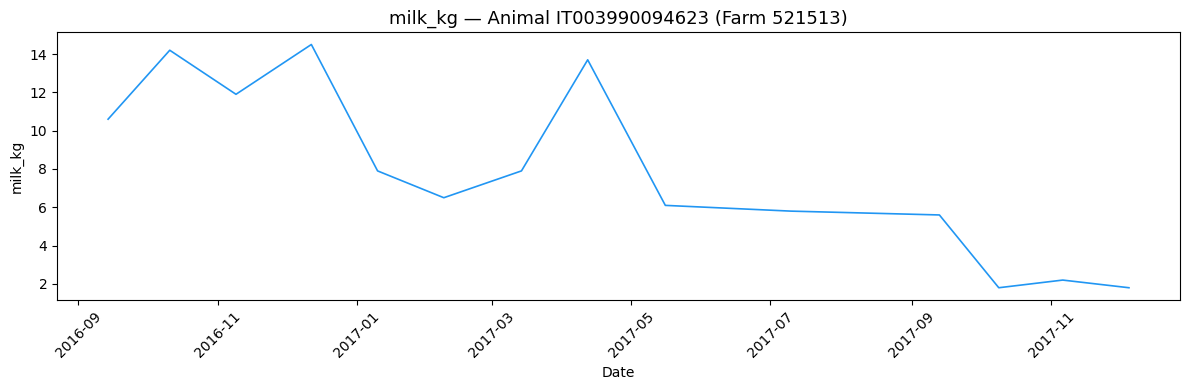

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── LOAD (only needed columns) ───────────────────────────────────────────────
hts = pd.read_csv("hts_long_panel.csv", parse_dates=["dtt"])


ANIMAL_ID   = "IT003990094623"          # ← change this
FARM_CODE   = "521513"                  # ← change this (needed to build series_id)
series_id   = f"{FARM_CODE}/{ANIMAL_ID}"

animal_df = (
    hts[hts["series_id"] == series_id]
    .sort_values("dtt")
    .reset_index(drop=True)
)

print(f"Records for {series_id}: {len(animal_df)}")
print(animal_df.head())
print(len(animal_df))

# ── PLOT ─────────────────────────────────────────────────────────────────────

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(animal_df["dtt"], animal_df["milk_kg"], linewidth=1.2, color="#2196F3")
ax.set_title(f"milk_kg — Animal {ANIMAL_ID} (Farm {FARM_CODE})", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("milk_kg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("animal_plot.png", dpi=150)
plt.show()





# ═════════════════════════════════
# OPTION B — retrieve & plot a specific FARM (farm-level series + all its animals)
# ═════════════════════════════════

Farm 1114232 — 552 animals, 120 farm-level records


/tmp/ipykernel_1153/642717841.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(animal_ids))
/tmp/ipykernel_1153/642717841.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


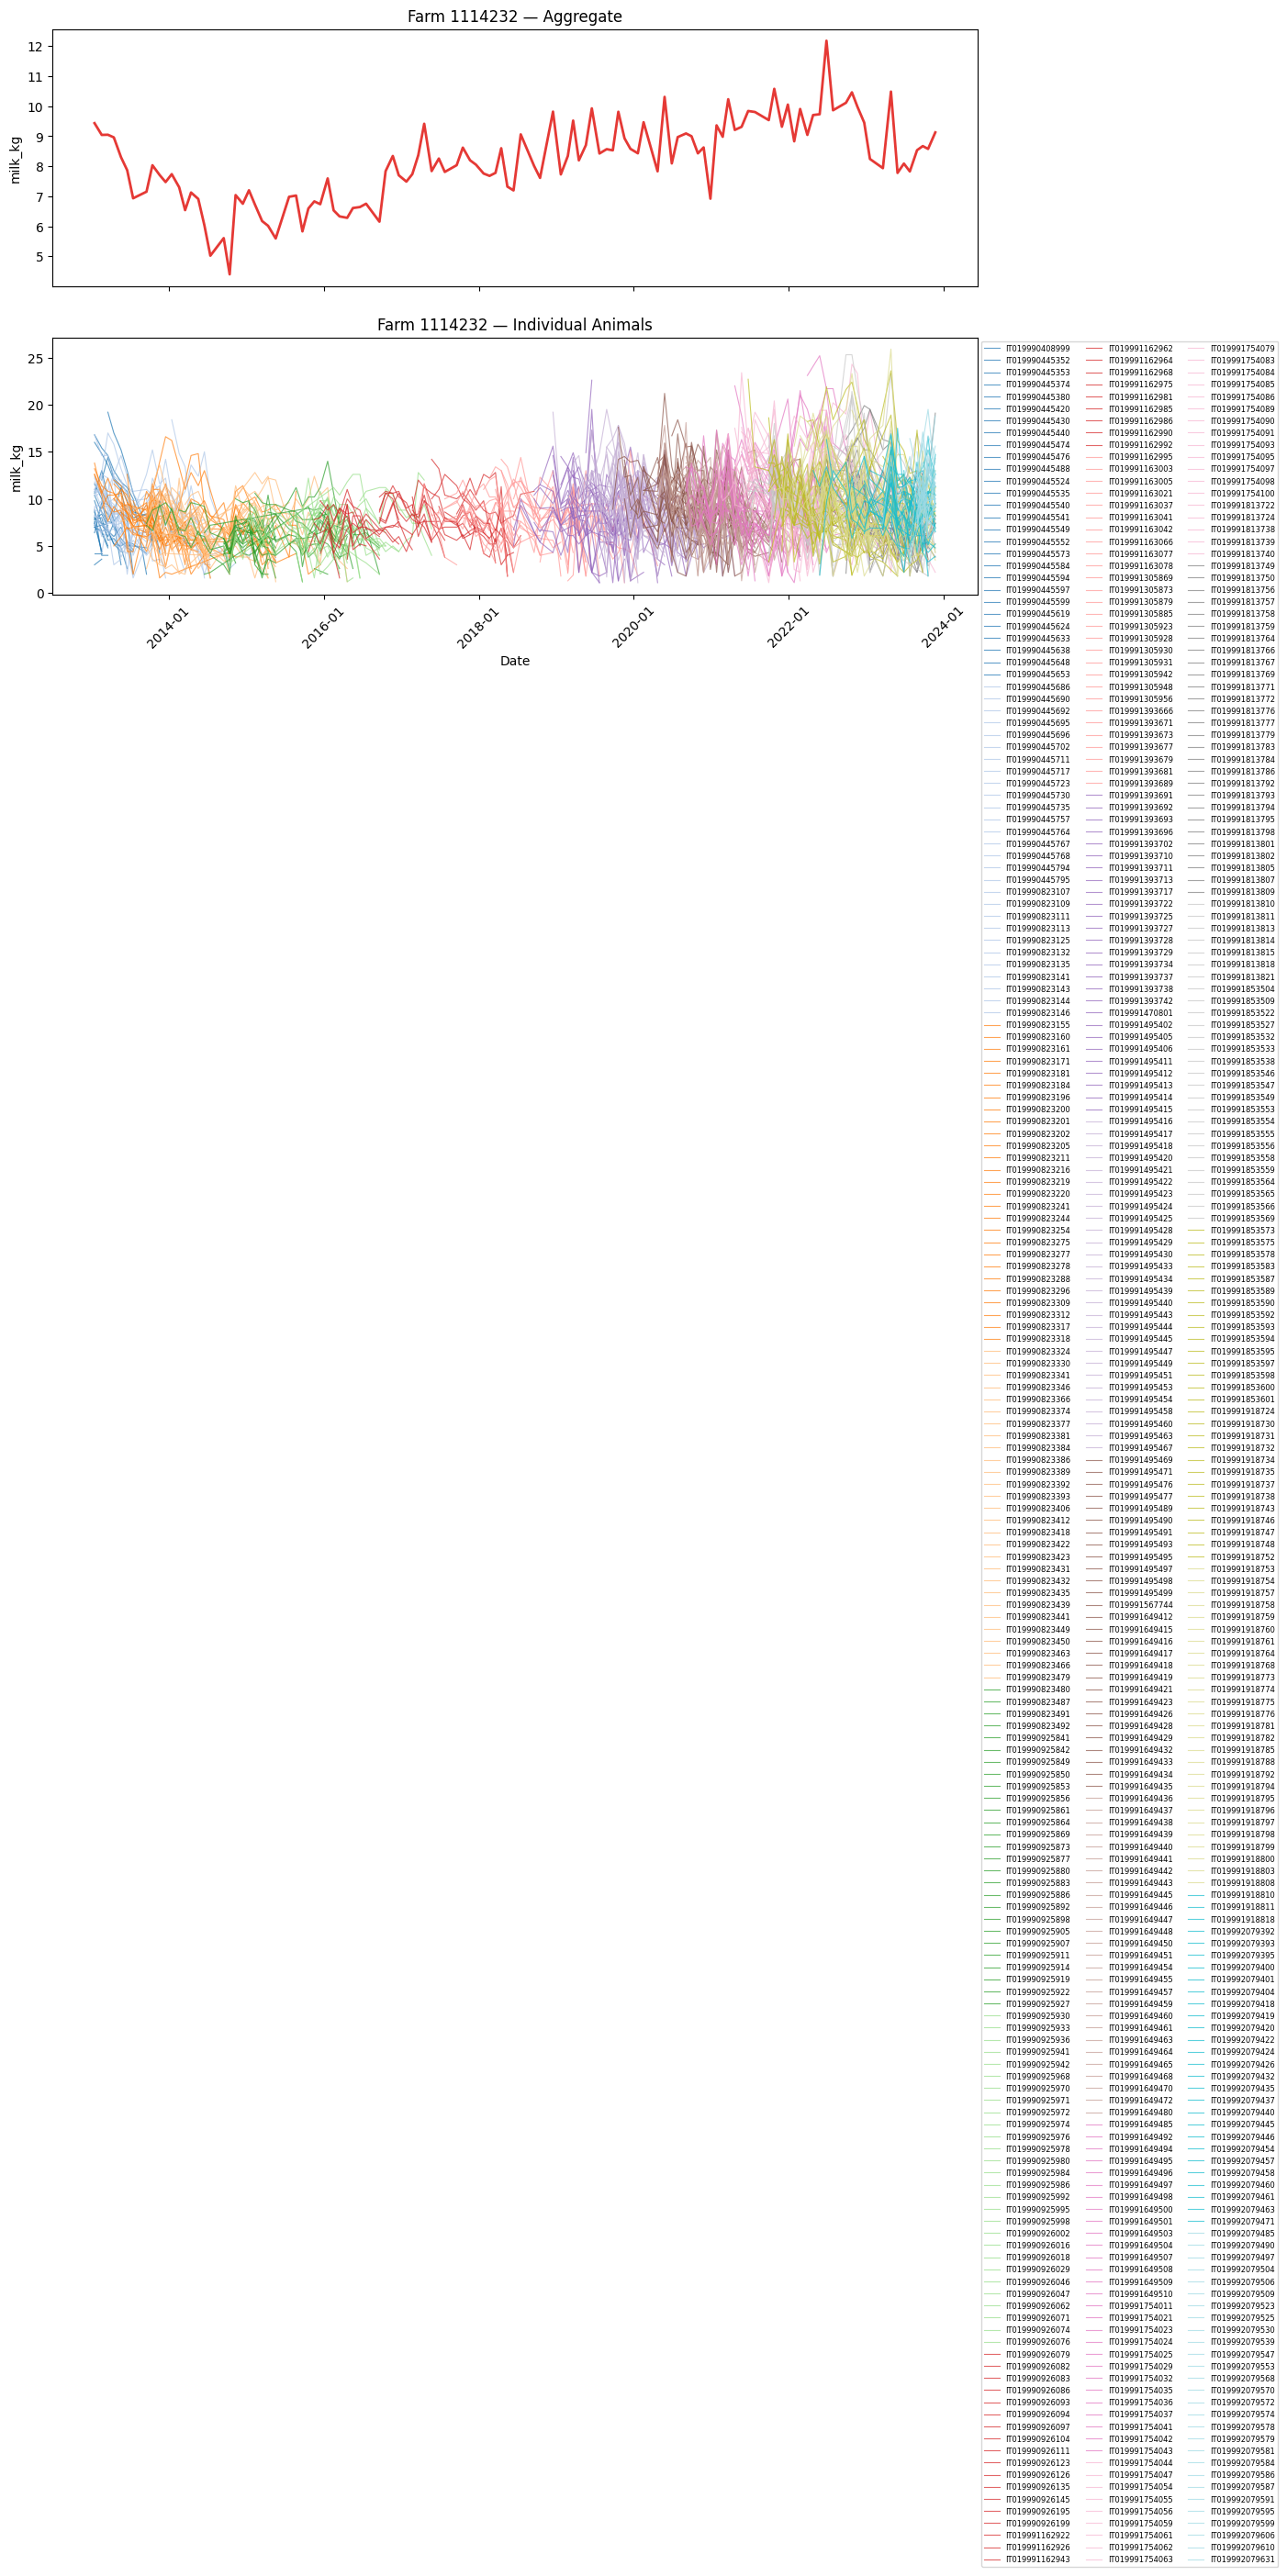

In [ ]:

FARM_CODE = "1114232"                    # ← change this

# Farm-level aggregate
farm_df = (
    hts[hts["series_id"] == f"Farm/{FARM_CODE}"]
    .sort_values("dtt")
    .reset_index(drop=True)
)

# All animals belonging to this farm
animals_df = (
    hts[hts["series_id"].str.startswith(f"{FARM_CODE}/")]
    .sort_values(["series_id", "dtt"])
    .reset_index(drop=True)
)

animal_ids = animals_df["series_id"].unique()
print(f"Farm {FARM_CODE} — {len(animal_ids)} animals, {len(farm_df)} farm-level records")

# Plot: farm aggregate on top, all animals below
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: farm aggregate
ax1.plot(farm_df["dtt"], farm_df["milk_kg"], color="#E53935", linewidth=2)
ax1.set_title(f"Farm {FARM_CODE} — Aggregate", fontsize=12)
ax1.set_ylabel("milk_kg")

# Bottom: individual animals (one line each)
cmap = plt.cm.get_cmap("tab20", len(animal_ids))
for k, sid in enumerate(animal_ids):
    sub = animals_df[animals_df["series_id"] == sid]
    ax2.plot(sub["dtt"], sub["milk_kg"], linewidth=0.8,
             alpha=0.7, color=cmap(k), label=sid.split("/")[1])

ax2.set_title(f"Farm {FARM_CODE} — Individual Animals", fontsize=12)
ax2.set_ylabel("milk_kg")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# Legend outside if many animals
if len(animal_ids) <= 15:
    ax2.legend(fontsize=7, loc="upper left", ncol=2)
else:
    ax2.legend(fontsize=6, loc="upper left", ncol=3, bbox_to_anchor=(1, 1))

plt.tight_layout()
# plt.savefig("farm_plot.png", dpi=150, bbox_inches="tight")
plt.show()



# ═════════════════════════════════
# OPTION C — quick lookup helpers (use anytime)
# ═════════════════════════════════


In [ ]:

def get_animal(hts_df, farm_code, animal_id):
    """Return time series for one animal."""
    sid = f"{farm_code}/{animal_id}"
    return hts_df[hts_df["series_id"] == sid].sort_values("dtt").reset_index(drop=True)

def get_farm(hts_df, farm_code):
    """Return farm-level aggregate series."""
    return hts_df[hts_df["series_id"] == f"Farm/{farm_code}"].sort_values("dtt").reset_index(drop=True)

def get_farm_animals(hts_df, farm_code):
    """Return all animal-level series for a farm, as a wide DataFrame."""
    sub = hts_df[hts_df["series_id"].str.startswith(f"{farm_code}/")]
    return sub.pivot(index="dtt", columns="series_id", values="milk_kg").sort_index()

def list_farms(hts_df):
    """List all available farm codes."""
    return [s.replace("Farm/", "") for s in hts_df["series_id"].unique() if s.startswith("Farm/")]

def list_animals(hts_df, farm_code):
    """List all animal IDs for a given farm."""
    prefix = f"{farm_code}/"
    return [s.replace(prefix, "") for s in hts_df["series_id"].unique() if s.startswith(prefix)]

# Example usage:
# print(list_farms(hts))
# print(list_animals(hts, "521513"))
# df = get_animal(hts, "521513", "IT003990094624")
# wide = get_farm_animals(hts, "521513")   # pivot only ONE farm → safe RAM-wise

# claude method 2


In [3]:
import pandas as pd
import numpy as np

CHUNKSIZE = 50_000
DATE_COL  = "dtt"

TARGETS = ["milk_kg", "protein_p"]

# Numeric covariates (exogenous features)
COVARIATES = [
    "fat_p", "cells", "NM", "ECM", "SCS",                          # milk quality
    "temperature_avg", "temperature_max", "temperature_min",         # weather
    "humidity_avg", "humidity_max", "humidity_min",
    "wind_speed_avg", "wind_speed_max", "wind_speed_min",
    "THI_1_avg", "THI_1_min", "THI_1_max",                         # heat stress
    "THI_2_avg", "THI_2_min", "THI_2_max",
    "WHI_avg", "WHI_min", "WHI_max",
    "parity",                                                        # animal info
]

# These are categorical/date animal-level info — we'll handle separately
META_COLS = ["AFC", "DIM"]

READ_COLS = ["Farm_Code", "Animal_ID", DATE_COL] + TARGETS + COVARIATES + META_COLS

animal_records = []
farm_records   = []
total_records  = []

chunk_iter = pd.read_csv(
    path + '/Final_Data/Merged_Data_Scaled_Processed.csv',
    usecols=READ_COLS,
    chunksize=CHUNKSIZE,
    parse_dates=[DATE_COL],
)

for i, chunk in enumerate(chunk_iter):
    chunk["Farm_Code"] = chunk["Farm_Code"].astype(str)
    chunk = chunk.dropna(subset=TARGETS, how="all")

    GROUP_ANIMAL = [DATE_COL, "Farm_Code", "Animal_ID"]
    GROUP_FARM   = [DATE_COL, "Farm_Code"]
    GROUP_TOTAL  = [DATE_COL]

    agg_cols = TARGETS + COVARIATES  # all numeric → mean aggregation

    # ── ANIMAL level ────────────────────────────────────────────────────────
    agg_animal = chunk.groupby(GROUP_ANIMAL)[agg_cols].mean().reset_index()
    agg_animal["series_id"] = agg_animal["Farm_Code"] + "/" + agg_animal["Animal_ID"]
    agg_animal["level"] = "animal"
    animal_records.append(agg_animal.drop(columns=["Farm_Code", "Animal_ID"]))

    # ── FARM level ──────────────────────────────────────────────────────────
    agg_farm = chunk.groupby(GROUP_FARM)[agg_cols].mean().reset_index()
    agg_farm["series_id"] = "Farm/" + agg_farm["Farm_Code"]
    agg_farm["level"] = "farm"
    farm_records.append(agg_farm.drop(columns=["Farm_Code"]))

    # ── TOTAL level ─────────────────────────────────────────────────────────
    agg_total = chunk.groupby(GROUP_TOTAL)[agg_cols].mean().reset_index()
    agg_total["series_id"] = "Total"
    agg_total["level"] = "total"
    total_records.append(agg_total)

    if i % 10 == 0:
        print(f"  Chunk {i} processed...")

# ── Final aggregation across chunks ─────────────────────────────────────────
print("Finalizing...")

def finalize(records, group_keys):
    df = pd.concat(records)
    return df.groupby(group_keys)[agg_cols].mean().reset_index()

animal_long = finalize(animal_records, [DATE_COL, "series_id", "level"])
farm_long   = finalize(farm_records,   [DATE_COL, "series_id", "level"])
total_long  = finalize(total_records,  [DATE_COL, "series_id", "level"])

hts_long = pd.concat([total_long, farm_long, animal_long], ignore_index=True)
hts_long = hts_long.sort_values(["series_id", DATE_COL]).reset_index(drop=True)

print(f"HTS panel shape: {hts_long.shape}")
print(hts_long.head())

hts_long.to_csv("hts_long_panel_full.csv", index=False)
print("✅ Saved: hts_long_panel_full.csv")

  Chunk 0 processed...
  Chunk 10 processed...
Finalizing...
HTS panel shape: (748863, 29)
         dtt               series_id   level  milk_kg  protein_p  fat_p  \
0 2013-01-16  1114232/IT019990408999  animal      8.0       5.06  10.36   
1 2013-01-16  1114232/IT019990445352  animal      8.8       5.19   8.81   
2 2013-02-19  1114232/IT019990445352  animal      4.0       5.39  10.00   
3 2013-03-20  1114232/IT019990445352  animal      4.0       5.14   7.69   
4 2013-01-16  1114232/IT019990445353  animal      7.0       4.93  10.08   

    cells   NM        ECM       SCS  ...  THI_1_avg  THI_1_min  THI_1_max  \
0   176.0  2.0  15.687680  3.815575  ...     35.665     34.216     37.230   
1    53.0  2.0  15.813160  2.084064  ...     35.665     34.216     37.230   
2   232.0  2.0   7.829980  4.214125  ...     40.607     35.990     48.197   
3  1515.0  2.0   6.647260  6.921246  ...     41.450     34.266     48.103   
4   113.0  2.0  13.395235  3.176323  ...     35.665     34.216     37.230


── Feature importance for: milk_kg ──
  Training on 546,060 rows, 26 features

  Top 10 features for milk_kg:
ECM                0.871236
fat_p              0.128764
cells              0.000000
NM                 0.000000
SCS                0.000000
temperature_avg    0.000000
temperature_max    0.000000
temperature_min    0.000000
humidity_avg       0.000000
humidity_max       0.000000

── Feature importance for: protein_p ──
  Training on 546,060 rows, 26 features

  Top 10 features for protein_p:
protein_p_lag1    0.627737
fat_p             0.286232
protein_p_lag2    0.060930
ECM               0.011370
parity            0.008315
SCS               0.001259
cells             0.001253
wind_speed_max    0.000736
wind_speed_avg    0.000359
humidity_min      0.000285


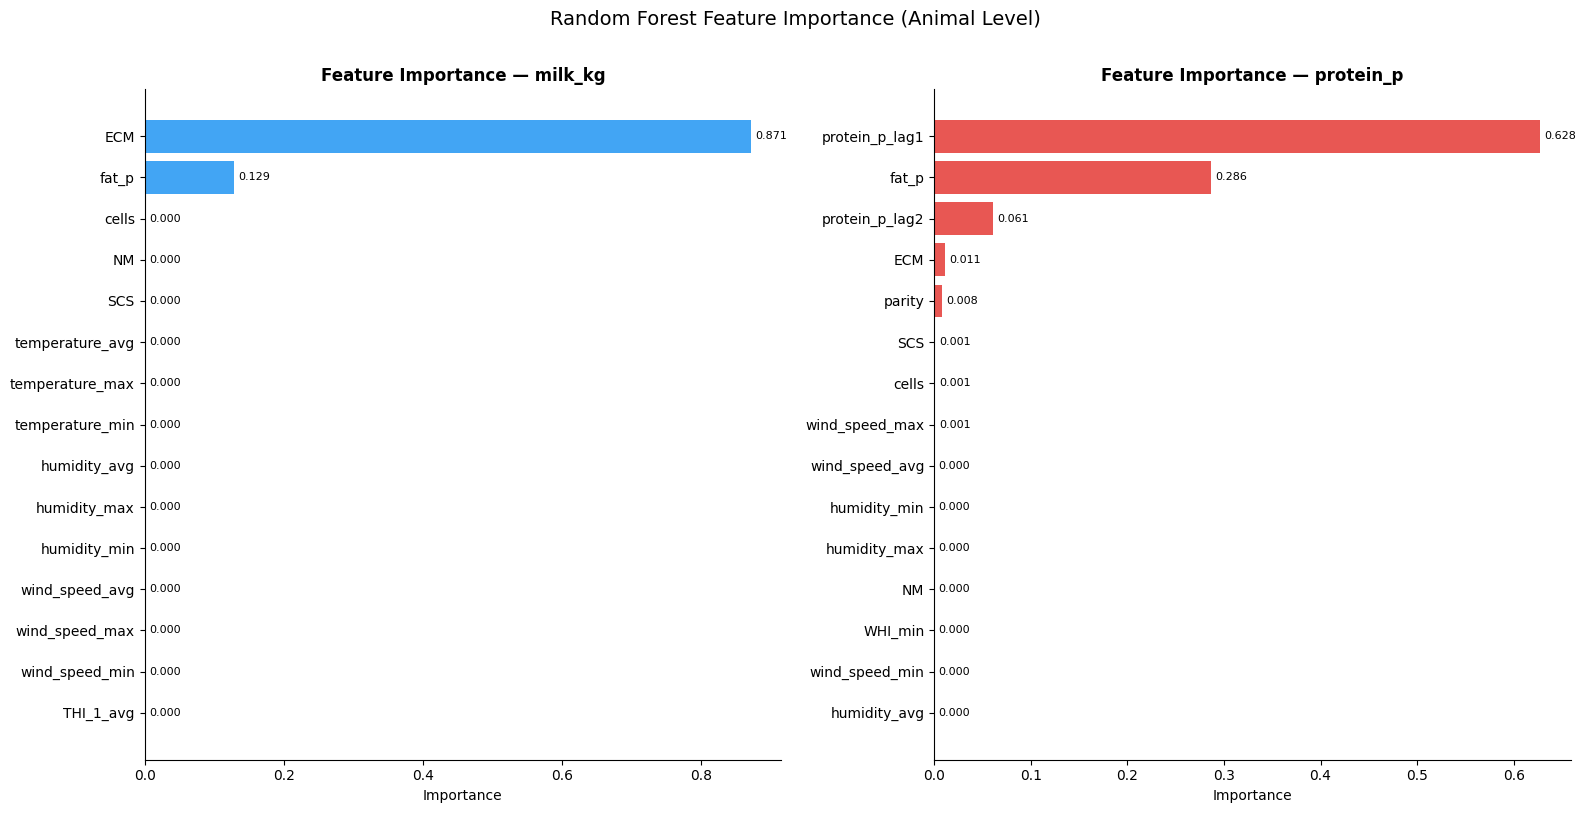

✅ Saved: feature_importance_milk_kg.csv, feature_importance_protein_p.csv


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

hts = pd.read_csv("hts_long_panel_full.csv", parse_dates=[DATE_COL])

TARGETS    = ["milk_kg", "protein_p"]
COVARIATES = [
    "fat_p", "cells", "NM", "ECM", "SCS",
    "temperature_avg", "temperature_max", "temperature_min",
    "humidity_avg", "humidity_max", "humidity_min",
    "wind_speed_avg", "wind_speed_max", "wind_speed_min",
    "THI_1_avg", "THI_1_min", "THI_1_max",
    "THI_2_avg", "THI_2_min", "THI_2_max",
    "WHI_avg", "WHI_min", "WHI_max",
    "parity",
]
DATE_COL = "dtt"

# Use animal-level data only
animal_data = hts[hts["level"] == "animal"].copy()

# Add lag features (t-1, t-2) for each target — important for time series
LAG_STEPS = [1, 2]

importance_results = {}

for target in TARGETS:
    print(f"\n── Feature importance for: {target} ──")

    # Work on a copy sorted by series and date
    df = animal_data[["series_id", DATE_COL, target] + COVARIATES].copy()
    df = df.sort_values(["series_id", DATE_COL])

    # Add lags per series
    for lag in LAG_STEPS:
        df[f"{target}_lag{lag}"] = df.groupby("series_id")[target].shift(lag)

    lag_features = [f"{target}_lag{lag}" for lag in LAG_STEPS]
    feature_cols = COVARIATES + lag_features

    df = df.dropna(subset=[target] + feature_cols)

    X = df[feature_cols]
    y = df[target]

    print(f"  Training on {len(X):,} rows, {len(feature_cols)} features")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X, y)

    importance = pd.Series(rf.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=False)
    importance_results[target] = importance

    print(f"\n  Top 10 features for {target}:")
    print(importance.head(10).to_string())

# ── Plot side by side ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(TARGETS), figsize=(16, 8))

colors = {"milk_kg": "#2196F3", "protein_p": "#E53935"}

for ax, target in zip(axes, TARGETS):
    imp = importance_results[target].head(15)
    bars = ax.barh(imp.index[::-1], imp.values[::-1], color=colors[target], alpha=0.85)
    ax.set_title(f"Feature Importance — {target}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Random Forest Feature Importance (Animal Level)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Save importance tables
for target, imp in importance_results.items():
    imp.to_csv(f"feature_importance_{target}.csv", header=["importance"])
print("✅ Saved: feature_importance_milk_kg.csv, feature_importance_protein_p.csv")

In [ ]:
# After running Step 2, use this to filter to only important features
IMPORTANCE_THRESHOLD = 0.02   # drop features below 2% importance

selected_features = {}
for target, imp in importance_results.items():
    selected = imp[imp >= IMPORTANCE_THRESHOLD].index.tolist()
    # Remove lag features from covariate list (they're targets, not exogenous)
    selected_covariates = [f for f in selected if "lag" not in f]
    selected_features[target] = selected_covariates
    print(f"\n{target} — selected covariates ({len(selected_covariates)}):")
    print(selected_covariates)

# Save for use in forecasting step
import json
with open("selected_features.json", "w") as f:
    json.dump(selected_features, f, indent=2)
print("\n✅ Saved: selected_features.json")

## Gemini Method


### Step 1: Preprocess the Data

In [ ]:
import pandas as pd

# 1. Load and parse dates
df = pd.read_csv(path + '/Final_Data/Merged_Data_Scaled_Processed.csv')
df = convert_types(df)
df['dtt'] = pd.to_datetime(df['dtt'])

# 2. Select relevant columns
ts_df = df[['Farm_Code', 'Animal_ID', 'dtt', 'milk_kg']].copy()

# 3. Create a unique identifier for the bottom level
ts_df['Animal_Key'] = ts_df['Farm_Code'].astype(str) + "_" + ts_df['Animal_ID'].astype(str)
ts_df = ts_df.rename(columns={'dtt': 'ds', 'milk_kg': 'y'})

# 4. Resample to a regular frequency (e.g., Monthly 'ME')
ts_df = ts_df.set_index('ds').groupby('Animal_Key').resample('ME')['y'].sum().reset_index()

In [ ]:
# 5. SAVE TO CSV
ts_df.to_csv('preprocessed_hts_data.csv', index=False)
print("Step 1 complete. Data saved to preprocessed_hts_data.csv")

Step 1 complete. Data saved to preprocessed_hts_data.csv


### Step 2: Build the Hierarchy aggregation

In [ ]:
%%capture
!pip install hierarchicalforecast statsforecast

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import gc

# 1. Load data
ts_df = pd.read_csv('preprocessed_hts_data.csv', parse_dates=['ds'])
ts_df['Farm'] = ts_df['Animal_Key'].apply(lambda x: x.split('_')[0])

print("Aggregating Y_df...")
# Build levels manually
bottom_df = ts_df[['Animal_Key', 'ds', 'y']].rename(columns={'Animal_Key': 'unique_id'})
farm_df = ts_df.groupby(['Farm', 'ds'])['y'].sum().reset_index().rename(columns={'Farm': 'unique_id'})
total_df = ts_df.groupby('ds')['y'].sum().reset_index()
total_df['unique_id'] = 'Total'

Y_df = pd.concat([total_df, farm_df, bottom_df], ignore_index=True)

# Free up memory immediately
del ts_df, total_df, farm_df, bottom_df
gc.collect()

print("Extracting unique nodes...")
unique_farms = list(Y_df[Y_df['unique_id'].str.contains('_') == False]['unique_id'].unique())
unique_farms.remove('Total')
unique_animals = list(Y_df[Y_df['unique_id'].str.contains('_')]['unique_id'].unique())

tags = {
    'Farm': np.array(unique_farms),
    'Farm/Animal_Key': np.array(unique_animals)
}

print("Building Sparse S_df matrix...")
# 2. Build S_df as a Sparse Matrix
all_nodes = ['Total'] + unique_farms + unique_animals
node_to_row = {node: i for i, node in enumerate(all_nodes)}

rows = []
cols = []
vals = []

# Populate the sparse coordinates
for col_idx, animal in enumerate(unique_animals):
    farm = animal.split('_')[0]

    # Every animal column has exactly three '1's:
    # 1. At the Total row
    rows.append(node_to_row['Total'])
    cols.append(col_idx)
    vals.append(1)

    # 2. At its specific Farm row
    rows.append(node_to_row[farm])
    cols.append(col_idx)
    vals.append(1)

    # 3. At its own Animal row
    rows.append(node_to_row[animal])
    cols.append(col_idx)
    vals.append(1)

# Create the SciPy sparse matrix (COO format is extremely fast for building)
# Using uint8 to keep it as tiny as possible
S_sparse = coo_matrix((vals, (rows, cols)), shape=(len(all_nodes), len(unique_animals)), dtype=np.uint8)

# Convert directly to a Pandas DataFrame with Sparse data types
S_df = pd.DataFrame.sparse.from_spmatrix(S_sparse, index=all_nodes, columns=unique_animals)

print("Step 2 completed successfully! RAM usage optimized.")

Aggregating Y_df...
Extracting unique nodes...
Building Sparse S_df matrix...
Step 2 completed successfully! RAM usage optimized.


### Step 3: Train Base Models

In [ ]:
%%capture


In [ ]:
# Generate base forecasts
sf = StatsForecast(models=models, freq='M', n_jobs=-1)

# FIT AND PREDICT WITH 'fitted=True'
Y_hat_df = sf.forecast(df=Y_df_filtered, h=6, fitted=True)

# Extract the in-sample fitted values
Y_fitted_df = sf.forecast_fitted_values()
# Drop the duplicate 'y' column so we don't get overlapping names
Y_fitted_df = Y_fitted_df.drop(columns=['y'], errors='ignore')

# Merge the predictions into your historical dataframe
Y_df_filtered = Y_df_filtered.merge(Y_fitted_df, on=['unique_id', 'ds'], how='left')

print("Fitted values added! Ready for MinTrace.")

Fitted values added! Ready for MinTrace.


/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


### Step 4: Reconcile the Forecasts

In [ ]:
import numpy as np
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.core import HierarchicalReconciliation

# --- Align S_df and tags with the filtered Y_hat_df ---
valid_ids = set(Y_hat_df['unique_id'].unique())

# 1. Filter rows in S_df
if 'unique_id' not in S_df.columns:
    S_df = S_df.reset_index(names='unique_id')
S_df_filtered = S_df[S_df['unique_id'].isin(valid_ids)].copy()

# 2. Filter columns in S_df
valid_columns = [col for col in S_df_filtered.columns if col == 'unique_id' or col in valid_ids]
S_df_filtered = S_df_filtered[valid_columns]

# 3. Filter the tags dictionary
tags_filtered = {}
for level_name, nodes in tags.items():
    valid_nodes_for_level = [node for node in nodes if node in valid_ids]
    if len(valid_nodes_for_level) > 0:
        tags_filtered[level_name] = np.array(valid_nodes_for_level)

print(f"S_df shape reduced to {S_df_filtered.shape}")
# -----------------------------------------------------------

# Change this inside your reconcilers list in Step 4
reconcilers = [
    BottomUp(),
    MinTrace(method='wls_struct')  # Uses structural weights instead of residuals
]

# Initialize the reconciler
hforecast = HierarchicalReconciliation(reconcilers=reconcilers)

# Apply reconciliation
Y_rec_df = hforecast.reconcile(
    Y_hat_df=Y_hat_df,
    Y_df=Y_df_filtered,
    S_df=S_df_filtered,
    tags=tags_filtered
)

print(Y_rec_df.head())

S_df shape reduced to (3848, 3570)


Exception: min_trace (wls_struct) is ill-conditioned. Please use another reconciliation method.